<a href="https://colab.research.google.com/github/G1gg1l3ws/tc-20262-g1gg1l3ws/blob/main/Automata_lib_aula_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
# @title Instalação
import warnings
warnings.filterwarnings('ignore')
!apt install python3-dev graphviz libgraphviz-dev pkg-config -y > /dev/null 2>&1
!pip install pygraphviz coloraide automata-lib > /dev/null 2>&1
import os.path as opath
if not opath.exists('TCUtil'):
  !git clone https://github.com/TC-Rep/TCUtil.git > /dev/null 2>&1

from automata.base.exceptions import RejectionException
from TCUtil.util import validate_string, print_rastreamento, print_rastreamento_dfa, convert_to_dfa
from TCUtil.draw import drawgv_NFA
from PIL import Image
print("Instalação concluída")

Instalação concluída


In [39]:
from automata.fa.dfa import DFA
from automata.fa.nfa import NFA
from automata.fa.gnfa import GNFA

---
## 01
Sobre $\Sigma = \{a, b\}$, construa um AFD que aceite cadeias de comprimento $\ge 1$ cujo primeiro símbolo seja estritamente igual ao último.

Mostre o passo a passo do processamento da string 'ababaa'.

b(aa*b|b)*|a(bb*a|a)*


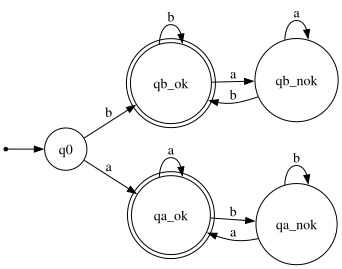

In [ ]:
dfa_extremos = DFA(
    states={'q0', 'qa_ok', 'qa_nok', 'qb_ok', 'qb_nok'},
    input_symbols={'a', 'b'},
    transitions={
        'q0': {
            'a': 'qa_ok',
            'b': 'qb_ok'
        },
        # Ramo que iniciou com 'a'
        'qa_ok': {
            'a': 'qa_ok',   # Permanece aceitando
            'b': 'qa_nok'   # Termina em b, deixa de aceitar
        },
        'qa_nok': {
            'a': 'qa_ok',   # Volta a terminar em a, aceita
            'b': 'qa_nok'   # Continua em b, não aceita
        },
        # Ramo que iniciou com 'b'
        'qb_ok': {
            'a': 'qb_nok',  # Termina em a, deixa de aceitar
            'b': 'qb_ok'    # Permanece aceitando
        },
        'qb_nok': {
            'a': 'qb_nok',  # Continua em a, não aceita
            'b': 'qb_ok'    # Volta a terminar em b, aceita
        }
    },
    initial_state='q0',
    final_states={'qa_ok', 'qb_ok'}
)

gnfa1 = GNFA.from_dfa(dfa_extremos)
print(gnfa1.to_regex())

dfa_extremos.show_diagram()


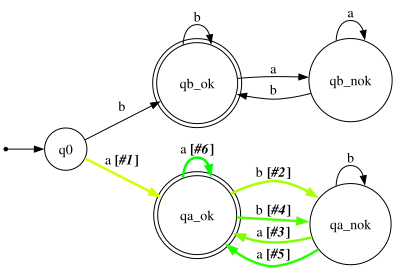

In [ ]:
# Simulação
cadeia = 'ababaa'
dfa_extremos.show_diagram(cadeia)

---
##02
Sobre $\Sigma = \{0, 1, 2\}$, aceite palavras formadas por: um bloco de 0s (qualquer quantidade), seguido por um bloco de 1s de tamanho ímpar, seguido opcionalmente por um bloco de 2s. Use $\varepsilon$-transições para conectar as três fases.
Na sequência, mostre o rastreamento dos estados alcançados para o string '011122'

0*1(11)*(2*)?


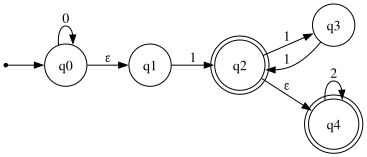

In [ ]:
from automata.fa.nfa import NFA
from automata.fa.dfa import DFA
from IPython.display import Image, display

# 1. Definição formal do AFN: L = 0* 1(11)* 2*
# Nota: na automata-lib, transição epsilon (vazia) é representada por ''
nfa_fases = NFA(
    states={'q0', 'q1', 'q2', 'q3', 'q4'},
    input_symbols={'0', '1', '2'},
    transitions={
        # Fase 1: Bloco de '0's (qualquer quantidade)
        'q0': {
            '0': {'q0'},
            '': {'q1'}     # Transição epsilon para início dos '1's
        },
        # Fase 2: Bloco de '1's com tamanho ímpar
        'q1': {
            '1': {'q2'}     # Lê o 1º símbolo '1'
        },
        'q2': {
            '1': {'q3'},    # 2º símbolo '1' (par)
            '': {'q4'}      # Transição epsilon para a fase dos '2's
        },
        'q3': {
            '1': {'q2'}     # 3º símbolo '1' (ímpar novamente)
        },
        # Fase 3: Bloco opcional de '2's
        'q4': {
            '2': {'q4'}
        }
    },
    initial_state='q0',
    final_states={'q2', 'q4'}
)

print(GNFA.from_nfa(nfa_fases).to_regex())

nfa_fases.show_diagram()

Rastreamento de todos os estados alcançados:
δ({'q0', 'q1'},0) -> {'q0', 'q1'}
δ({'q0', 'q1'},1) -> {'q2', 'q4'}
δ({'q2', 'q4'},1) -> {'q3'}
δ({'q3'},1) -> {'q2', 'q4'}
δ({'q2', 'q4'},2) -> {'q4'}
δ({'q4'},2) -> {'q4'}


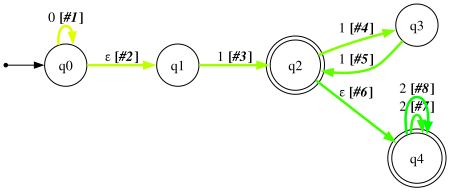

In [ ]:
cadeia='011122'
gen = nfa_fases.read_input_stepwise(cadeia)
print_rastreamento(gen,nfa_fases,cadeia)
nfa_fases.show_diagram(cadeia)

---
##03
Equivalência de expressões regulares
Crie AFD e AFN para reconhecer a linguagem formada por sequência de a's seguida de sequência de b's, seguida por sequência de c's.

Compare as linguagens dos dois autômatos para saber se reconhecem a mesma linguagem.

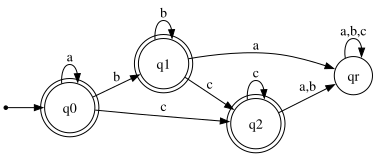

In [41]:
dfa_abc = DFA(
    states={'q0', 'q1', 'q2', 'qr'},
    input_symbols={'a', 'b', 'c'},
    transitions={
        'q0': {
            'a': 'q0',      # Continua nos a's
            'b': 'q1',      # Começou os b's
            'c': 'q2'       # Pulou b's e foi direto para os c's
        },
        'q1': {
            'a': 'qr',    # Ordem violada: 'a' depois de 'b'
            'b': 'q1',      # Continua nos b's
            'c': 'q2'       # Começou os c's
        },
        'q2': {
            'a': 'qr',    # Ordem violada: 'a' depois de 'c'
            'b': 'qr',    # Ordem violada: 'b' depois de 'c'
            'c': 'q2'       # Continua nos c's
        },
        'qr': {
            'a': 'qr',
            'b': 'qr',
            'c': 'qr'
        }
    },
    initial_state='q0',
    # q0, q1 e q2 são todos estados de aceitação
    final_states={'q0', 'q1', 'q2'}
)

dfa_abc.show_diagram()

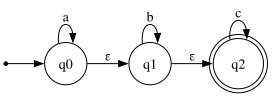

In [42]:
nfa_abc = NFA(
    states={'q0', 'q1', 'q2'},
    input_symbols={'a', 'b', 'c'},
    transitions={
        'q0': {'a': {'q0'}, '': {'q1'}},
        'q1': {'b': {'q1'}, '': {'q2'}},  # epsilon-transição para a fase do b
        'q2': {'c': {'q2'}}
    },
    initial_state='q0',
    final_states={'q2'}
)

nfa_abc.show_diagram()

In [ ]:
# Solução 1
# Calculando o DFA que aceita a diferença entre as linguagens
diff = dfa_abc.difference(DFA.from_nfa(nfa_abc)) # É necessário converter o AFN para AFD, pois o método difference da classe DFA compara apenas AFDs.
# Verificando se é vazia
print(diff.isempty())

True


In [44]:
# Solução 2
# Convertendo FAs para Expressões Regulares
from automata.regex import regex
gnfa1 = GNFA.from_dfa(dfa_abc)
gnfa2 = GNFA.from_nfa(nfa_abc)
re1 = gnfa1.to_regex()
re2 = gnfa2.to_regex()
# Verificando se são equivalentes
print(re1)
regex.isequal(re1,re2)

a*((bb*c|c)c*|(bb*)?)


True

---
##Exercícios

Para as linguagens a seguir, fazer o AFN e o AFD.
- Sobre $\Sigma = \{a, b\}$, aceite cadeias que tenham comprimento par OU terminem com a sequência aba.
- Sobre $\Sigma = \{a, b\}$, aceite cadeias onde o símbolo na posição $n-2$ é igual ao símbolo na posição $n$ (ou seja, o antepenúltimo e o último símbolos coincidem).
- Sobre $\Sigma = \{0, 1, 2, 3, 4, 5, 6, 7, 8, 9\}$, aceite cadeias onde o número inteiro formado seja múltiplo de 5.

## Ex. 1

AFN:  True
AFN:  False
AFN:  True
AFD:  True
AFD:  False
AFD:  True


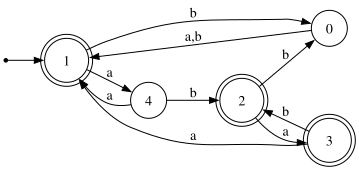

In [34]:

afn_aba = NFA(
              input_symbols={'a','b'},
              states= {'q0','q1','q2','q3','q4','q5','q6'},
              initial_state= 'q0',
              transitions= {
                'q0': {'':{'q1','q5'}},
                'q1': {'a':{'q2','q1'},'b':{'q1'}},
                'q2': {'b':{'q3'}},
                'q3': {'a':{'q4'}},
                'q4': {},
                'q5': {'a':{'q6'}, 'b':{'q6'}},
                'q6': {'a':{'q5'}, 'b':{'q5'}},
              },
              final_states={'q4','q5'}
)


print("AFN: ",afn_aba.accepts_input('aaba'))
print("AFN: ",afn_aba.accepts_input('bbbaa'))
print("AFN: ",afn_aba.accepts_input('ab'))
#afn_aba.show_diagram('aaba')

print("AFD: ",DFA.from_nfa(afn_aba).accepts_input('aaba'))
print("AFD: ",DFA.from_nfa(afn_aba).accepts_input('bbbaa'))
print("AFD: ",DFA.from_nfa(afn_aba).accepts_input('ab'))
DFA.from_nfa(afn_aba).show_diagram()


## Ex 2

REGEX ---> (a|b)*(a(a|b)a|b(a|b)b)
AFN:  True
AFN:  True
AFN:  True
AFN_MAN:  True
AFN_MAN:  True
AFN_MAN:  True
AFD:  True
AFD:  True
AFD:  True
REGEX e AFN are equivalent? --->  True


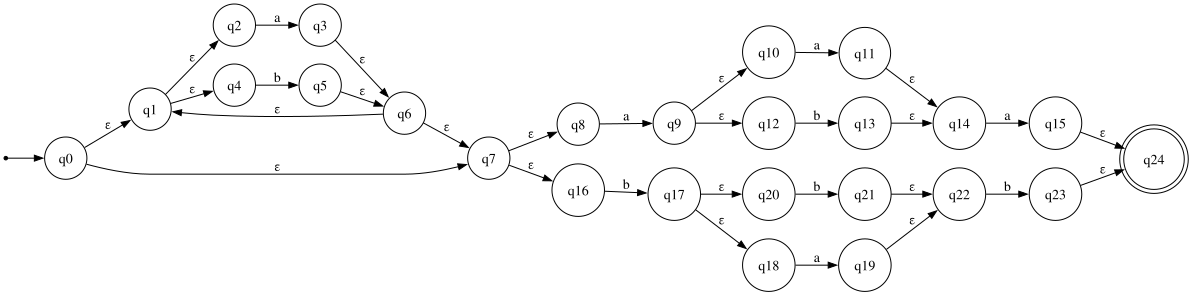

In [63]:
print(f"REGEX ---> (a|b)*(a(a|b)a|b(a|b)b)")

afn_pen = NFA.from_regex(regex='(a|b)*(a(a|b)a|b(a|b)b)', input_symbols={'a','b'})

afn_pen_man = NFA(
              input_symbols={'a','b'},
              states= {'q0','q1','q2','q3','q4','q5','q6','q7','q8','q9','q10',
                      'q11','q12','q13','q14','q15','q16','q17','q18','q19','q20',
                      'q21','q22','q23','q24'},
              initial_state= 'q0',
              transitions= {
                'q0': {'' : {'q1','q7'}},
                'q1': {'' : {'q2','q4'}},
                'q2': {'a': {'q3'}},
                'q3': {'' : {'q6'}},
                'q4': {'b': {'q5'}},
                'q5': {'' : {'q6'}},
                'q6': {'' : {'q7','q1'}},
                'q7': {'' : {'q8','q16'}},
                'q8': {'a': {'q9'}},
                'q9': {'' : {'q10','q12'}},
                'q10':{'a': {'q11'}},
                'q11':{'' : {'q14'}},
                'q12':{'b': {'q13'}},
                'q13':{'' : {'q14'}},
                'q14':{'a': {'q15'}},
                'q15':{'' : {'q24'}},
                'q16':{'b': {'q17'}},
                'q17':{'' : {'q18','q20'}},
                'q18':{'a': {'q19'}},
                'q19':{'' : {'q22'}},
                'q20':{'b': {'q21'}},
                'q21':{'' : {'q22'}},
                'q22':{'b': {'q23'}},
                'q23':{'' : {'q24'}},
              },
              final_states={'q24'}
)


print("AFN: ",afn_pen.accepts_input('aaba'))
print("AFN: ",afn_pen.accepts_input('bbbab'))
print("AFN: ",afn_pen.accepts_input('aba'))

print("AFN_MAN: ",afn_pen_man.accepts_input('aaba'))
print("AFN_MAN: ",afn_pen_man.accepts_input('bbbab'))
print("AFN_MAN: ",afn_pen_man.accepts_input('aba'))

print("AFD: ",DFA.from_nfa(afn_pen).accepts_input('aaba'))
print("AFD: ",DFA.from_nfa(afn_pen).accepts_input('bbbab'))
print("AFD: ",DFA.from_nfa(afn_pen).accepts_input('aba'))
#DFA.from_nfa(afn_pen).show_diagram()

print("REGEX e AFN are equivalent? ---> ",afn_pen_man == afn_pen)

afn_pen_man.show_diagram()

## Ex 3

REGEX ---> (1|2|3|4|5|6|7|8|9|0)*(5|0)
AFN:  False
AFN:  True
AFN:  True
AFD:  False
AFD:  True
AFD:  True


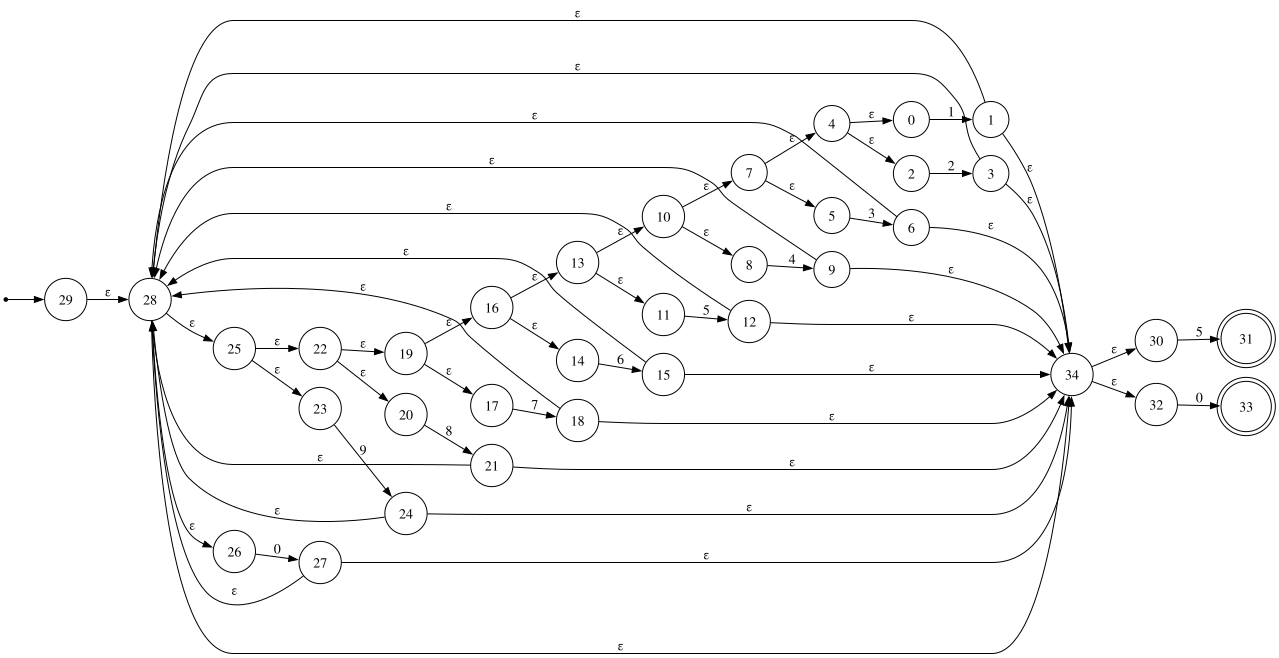

In [65]:
import re

print(f"REGEX ---> (1|2|3|4|5|6|7|8|9|0)*(5|0)")

afn_pen = NFA.from_regex(regex='(1|2|3|4|5|6|7|8|9|0)*(5|0)', input_symbols={'1','2','3','4','5','6','7','8','9','0',})
'''
afn_pen_man = NFA(
              input_symbols={'a','b'},
              states= {'q0','q1','q2','q3','q4','q5','q6','q7','q8','q9','q10',
                      'q11','q12','q13','q14','q15','q16','q17','q18','q19','q20',
                      'q21','q22','q23','q24'},
              initial_state= 'q0',
              transitions= {
                'q0': {'' : {'q1','q7'}},
                'q1': {'' : {'q2','q4'}},
                'q2': {'a': {'q3'}},
                'q3': {'' : {'q6'}},
                'q4': {'b': {'q5'}},
                'q5': {'' : {'q6'}},
                'q6': {'' : {'q7','q1'}},
                'q7': {'' : {'q8','q16'}},
                'q8': {'a': {'q9'}},
                'q9': {'' : {'q10','q12'}},
                'q10':{'a': {'q11'}},
                'q11':{'' : {'q14'}},
                'q12':{'b': {'q13'}},
                'q13':{'' : {'q14'}},
                'q14':{'a': {'q15'}},
                'q15':{'' : {'q24'}},
                'q16':{'b': {'q17'}},
                'q17':{'' : {'q18','q20'}},
                'q18':{'a': {'q19'}},
                'q19':{'' : {'q22'}},
                'q20':{'b': {'q21'}},
                'q21':{'' : {'q22'}},
                'q22':{'b': {'q23'}},
                'q23':{'' : {'q24'}},
              },
              final_states={'q24'}
)
'''

print("AFN: ",afn_pen.accepts_input('123'))
print("AFN: ",afn_pen.accepts_input('12345'))
print("AFN: ",afn_pen.accepts_input('0'))
'''
print("AFN_MAN: ",afn_pen_man.accepts_input('aaba'))
print("AFN_MAN: ",afn_pen_man.accepts_input('bbbab'))
print("AFN_MAN: ",afn_pen_man.accepts_input('aba'))
'''
print("AFD: ",DFA.from_nfa(afn_pen).accepts_input('123'))
print("AFD: ",DFA.from_nfa(afn_pen).accepts_input('12345'))
print("AFD: ",DFA.from_nfa(afn_pen).accepts_input('0'))
#DFA.from_nfa(afn_pen).show_diagram()

#print("REGEX e AFN are equivalent? ---> ",afn_pen_man == afn_pen)

afn_pen.show_diagram()